analysis of code processed by indel_scanner/processor.py

In [1]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path



In [2]:



INDEL_DIR_PATH = Path("/home/peterkad/pkadmaster/indel_scanner/results/test/")
INSERTIONS_CSV_PATH = INDEL_DIR_PATH / "processed_insertions.tsv"
DELETIONS_CSV_PATH = INDEL_DIR_PATH / "processed_deletions.tsv"

In [3]:
INSERTIONS = pd.read_csv(INSERTIONS_CSV_PATH, sep="\t")
DELETIONS = pd.read_csv(DELETIONS_CSV_PATH, sep="\t")

In [4]:
INSERTIONS.head()

,contig,ref_position,type,length,[sequence]_context,read_name,prefix_quality,insertion_quality,suffix_quality
0,h1tg000001l,11880,ins,1,TTTGT[G]GCTCT,m84108_250704_184541_s4/185862233/ccs,"90,90,89,58,73",49,"47,59,76,58,77"
1,h1tg000001l,13319,ins,2,GTTAA[AC]ACACA,m84108_250704_184541_s4/56297179/ccs,"93,93,68,93,93","59,93","93,93,93,93,90"
2,h1tg000001l,16924,ins,1,GTTTA[T]TATGA,m84108_250704_184541_s4/266931703/ccs,"93,93,93,93,93",80,"8,85,93,90,93"
3,h1tg000001l,19109,ins,1,TTAGG[T]TCTTG,m84108_250704_184541_s4/44437716/ccs,"44,32,36,46,24",28,"12,27,44,31,41"
4,h1tg000001l,20636,ins,1,GCTGT[C]CTGCA,m84108_250704_184541_s4/236326463/ccs,"73,88,93,89,93",93,"13,84,88,48,93"


# size distributions

In [19]:
inserted_SNPs = INSERTIONS[INSERTIONS['length'] == 1]
deleted_SNPs = DELETIONS[DELETIONS['length'] == 1]

In [20]:
inserted_not_SNPs = INSERTIONS[INSERTIONS['length'] > 1]
deleted_not_SNPs = DELETIONS[DELETIONS['length'] > 1]

In [11]:
inserted_SNPs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9005949 entries, 0 to 9809923
Data columns (total 9 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   contig              object
 1   ref_position        int64 
 2   type                object
 3   length              int64 
 4   [sequence]_context  object
 5   read_name           object
 6   prefix_quality      object
 7   insertion_quality   object
 8   suffix_quality      object
dtypes: int64(2), object(7)
memory usage: 687.1+ MB


In [12]:
inserted_not_SNPs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803975 entries, 1 to 9809890
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   contig              803975 non-null  object
 1   ref_position        803975 non-null  int64 
 2   type                803975 non-null  object
 3   length              803975 non-null  int64 
 4   [sequence]_context  803975 non-null  object
 5   read_name           803975 non-null  object
 6   prefix_quality      803975 non-null  object
 7   insertion_quality   803975 non-null  object
 8   suffix_quality      803975 non-null  object
dtypes: int64(2), object(7)
memory usage: 61.3+ MB


In [21]:
deleted_SNPs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16391652 entries, 0 to 18171803
Data columns (total 9 columns):
 #   Column              Dtype  
---  ------              -----  
 0   contig              object 
 1   ref_position        int64  
 2   type                object 
 3   length              int64  
 4   [sequence]_context  object 
 5   read_name           object 
 6   prefix_quality      object 
 7   insertion_quality   float64
 8   suffix_quality      object 
dtypes: float64(1), int64(2), object(6)
memory usage: 1.2+ GB


In [ ]:
deleted_not_SNPs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1780152 entries, 13 to 18171802
Data columns (total 9 columns):
 #   Column              Dtype  
---  ------              -----  
 0   contig              object 
 1   ref_position        int64  
 2   type                object 
 3   length              int64  
 4   [sequence]_context  object 
 5   read_name           object 
 6   prefix_quality      object 
 7   insertion_quality   float64
 8   suffix_quality      object 
dtypes: float64(1), int64(2), object(6)
memory usage: 135.8+ MB


<Axes: xlabel='length', ylabel='Count'>

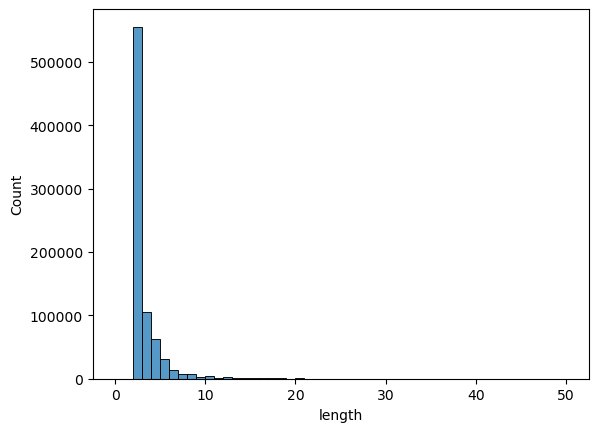

In [27]:
sns.histplot(inserted_not_SNPs['length'],bins=50,binrange=(0,50))

<Axes: xlabel='length', ylabel='Count'>

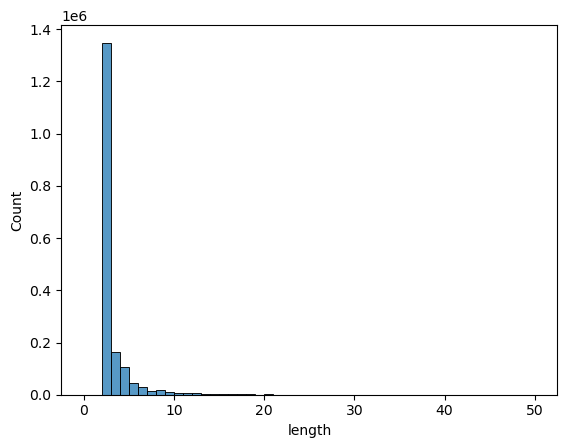

In [28]:
sns.histplot(deleted_not_SNPs['length'],bins=50,binrange=(0,50))

# qualities

In [33]:
pref_split =  inserted_SNPs['prefix_quality'].str.split(",", expand=True).astype(float)
suff_split =  inserted_SNPs['suffix_quality'].str.split(",", expand=True).astype(float)
pref_split.columns = [f"pref_{i+1}" for i in range(5)]
suff_split.columns = [f"suff_{i+1}" for i in range(5)]
pref_means = pref_split.mean(axis=0)
suff_means = suff_split.mean(axis=0)

In [38]:
plot_df = pd.DataFrame({
    "position": np.arange(1, 6),                     # 1 … 5
    "prefix_mean": pref_means.values,
    "suff_mean":   suff_means.values
}).melt(id_vars="position",
        value_vars=["prefix_mean", "suff_mean"],
        var_name="set",
        value_name="mean_quality")
plot_df.loc[plot_df["set"] == "prefix_mean", "position"] = -np.arange(5, 0, -1)   # -5,-4,-3,-2,-1
plot_df.loc[plot_df["set"] == "suff_mean",   "position"] =  np.arange(1, 6)

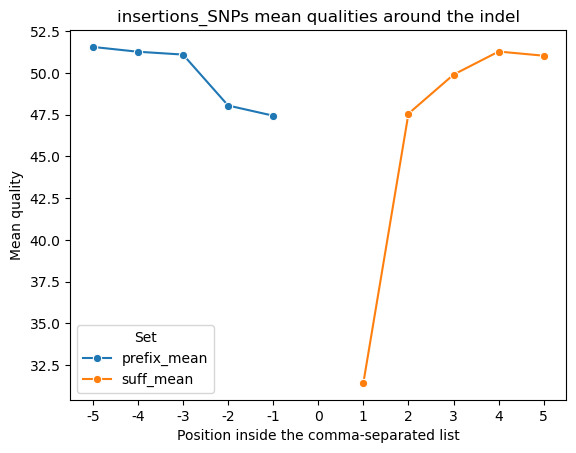

In [41]:
sns.lineplot(data=plot_df, x="position", y="mean_quality", hue="set", marker="o")
plt.title("insertions_SNPs mean qualities around the indel")
plt.xlabel("Position inside the comma‑separated list")
plt.xticks(ticks=np.arange(-5, 6), labels=[str(i) for i in range(-5, 6)])
plt.ylabel("Mean quality")       
plt.legend(title="Set")
plt.show()

In [ ]:
pref_split =  inserted_not_SNPs['prefix_quality'].str.split(",", expand=True).astype(float)
suff_split =  inserted_not_SNPs['suffix_quality'].str.split(",", expand=True).astype(float)
pref_split.columns = [f"pref_{i+1}" for i in range(5)]
suff_split.columns = [f"suff_{i+1}" for i in range(5)]
pref_means = pref_split.mean(axis=0)
suff_means = suff_split.mean(axis=0)

In [43]:
plot_df = pd.DataFrame({
    "position": np.arange(1, 6),                     # 1 … 5
    "prefix_mean": pref_means.values,
    "suff_mean":   suff_means.values
}).melt(id_vars="position",
        value_vars=["prefix_mean", "suff_mean"],
        var_name="set",
        value_name="mean_quality")
plot_df.loc[plot_df["set"] == "prefix_mean", "position"] = -np.arange(5, 0, -1)   # -5,-4,-3,-2,-1
plot_df.loc[plot_df["set"] == "suff_mean",   "position"] =  np.arange(1, 6)

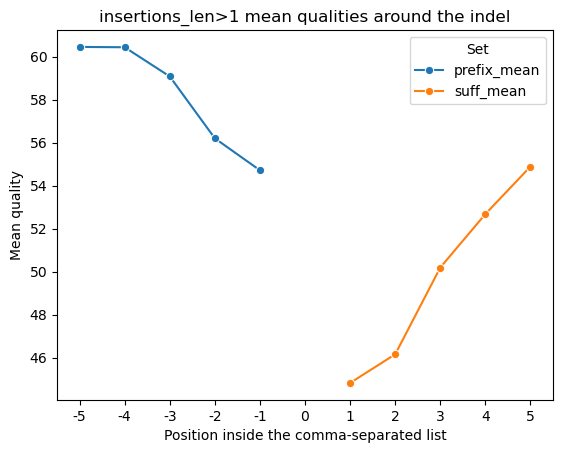

In [45]:
sns.lineplot(data=plot_df, x="position", y="mean_quality", hue="set", marker="o")
plt.title("insertions_len>1 mean qualities around the indel")
plt.xlabel("Position inside the comma‑separated list")
plt.xticks(ticks=np.arange(-5, 6), labels=[str(i) for i in range(-5, 6)])
plt.ylabel("Mean quality")       
plt.legend(title="Set")
plt.show()

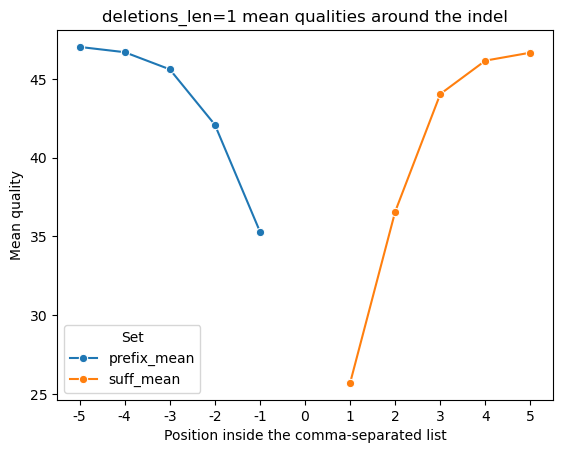

In [48]:
pref_split =  deleted_SNPs['prefix_quality'].str.split(",", expand=True).astype(float)
suff_split =  deleted_SNPs['suffix_quality'].str.split(",", expand=True).astype(float)
pref_split.columns = [f"pref_{i+1}" for i in range(5)]
suff_split.columns = [f"suff_{i+1}" for i in range(5)]
pref_means = pref_split.mean(axis=0)
suff_means = suff_split.mean(axis=0)

plot_df = pd.DataFrame({
    "position": np.arange(1, 6),                     # 1 … 5
    "prefix_mean": pref_means.values,
    "suff_mean":   suff_means.values
}).melt(id_vars="position",
        value_vars=["prefix_mean", "suff_mean"],
        var_name="set",
        value_name="mean_quality")
plot_df.loc[plot_df["set"] == "prefix_mean", "position"] = -np.arange(5, 0, -1)   # -5,-4,-3,-2,-1
plot_df.loc[plot_df["set"] == "suff_mean",   "position"] =  np.arange(1, 6)

sns.lineplot(data=plot_df, x="position", y="mean_quality", hue="set", marker="o")
plt.title("deletions_len=1 mean qualities around the indel")
plt.xlabel("Position inside the comma‑separated list")
plt.xticks(ticks=np.arange(-5, 6), labels=[str(i) for i in range(-5, 6)])
plt.ylabel("Mean quality")       
plt.legend(title="Set")
plt.show()

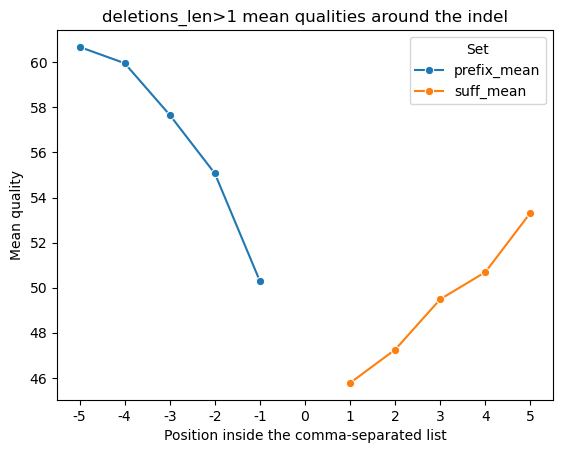

In [49]:
pref_split =  deleted_not_SNPs['prefix_quality'].str.split(",", expand=True).astype(float)
suff_split =  deleted_not_SNPs['suffix_quality'].str.split(",", expand=True).astype(float)
pref_split.columns = [f"pref_{i+1}" for i in range(5)]
suff_split.columns = [f"suff_{i+1}" for i in range(5)]
pref_means = pref_split.mean(axis=0)
suff_means = suff_split.mean(axis=0)

plot_df = pd.DataFrame({
    "position": np.arange(1, 6),                     # 1 … 5
    "prefix_mean": pref_means.values,
    "suff_mean":   suff_means.values
}).melt(id_vars="position",
        value_vars=["prefix_mean", "suff_mean"],
        var_name="set",
        value_name="mean_quality")
plot_df.loc[plot_df["set"] == "prefix_mean", "position"] = -np.arange(5, 0, -1)   # -5,-4,-3,-2,-1
plot_df.loc[plot_df["set"] == "suff_mean",   "position"] =  np.arange(1, 6)

sns.lineplot(data=plot_df, x="position", y="mean_quality", hue="set", marker="o")
plt.title("deletions_len>1 mean qualities around the indel")
plt.xlabel("Position inside the comma‑separated list")
plt.xticks(ticks=np.arange(-5, 6), labels=[str(i) for i in range(-5, 6)])
plt.ylabel("Mean quality")       
plt.legend(title="Set")
plt.show()

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_mean_quality_vs_length(
    df: pd.DataFrame,
    length_col: str = "length",
    prefix_col: str = "prefix_quality",
    suffix_col: str = "suffix_quality",
    figsize: tuple = (14, 5),
    palette: list = ["steelblue", "darkorange"],
    estimator: str = "mean",
    ci: int | None = None,
) -> plt.Figure:
    """
    Plot the **average quality** (mean of five comma‑separated values) 
    as a function of a numeric ``length`` column, in two separate subplots.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input table with columns: ``length_col``, ``prefix_col``, ``suffix_col``.
    length_col, prefix_col, suffix_col : str
        Column names in ``df``.
    figsize : tuple, optional
        Size of the figure (width, height).
    palette : list, optional
        Colours for prefix and suffix.
    estimator : str, optional
        Aggregation used by ``sns.lineplot`` (``"mean"``, ``"median"``, …).
    ci : int or None, optional
        Confidence‑interval band; ``None`` disables it.
    
    Returns
    -------
    plt.Figure
        The figure object.
    """
    
    # ─────────────────────────────────────────────────────────────────
    #  Split the comma‑separated strings and compute row‑wise means
    # ─────────────────────────────────────────────────────────────────
    pref_split = df[prefix_col].str.split(",", expand=True).astype(float)
    suff_split = df[suffix_col].str.split(",", expand=True).astype(float)
    
    pref_mean = pref_split.mean(axis=1)
    suff_mean = suff_split.mean(axis=1)
    
    # ─────────────────────────────────────────────────────────────────
    #  Create two DataFrames, one for each set
    # ─────────────────────────────────────────────────────────────────
    pref_df = pd.DataFrame({
        length_col: df[length_col],
        "mean_quality": pref_mean,
    })
    
    suff_df = pd.DataFrame({
        length_col: df[length_col],
        "mean_quality": suff_mean,
    })
    
    # ─────────────────────────────────────────────────────────────────
    #  Create two side‑by‑side subplots
    # ─────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Prefix plot (left)
    sns.lineplot(
        data=pref_df,
        x=length_col,
        y="mean_quality",
        markers=True,
        dashes=False,
        estimator=estimator,
        ci=ci,
        color=palette[0],  # steelblue
        ax=ax1
    )
    ax1.set_title("Prefix: Mean quality vs. length")
    ax1.set_xlabel("Length")
    ax1.set_ylabel("Mean quality")
    
    # Suffix plot (right)
    sns.lineplot(
        data=suff_df,
        x=length_col,
        y="mean_quality",
        markers=True,
        dashes=False,
        estimator=estimator,
        ci=ci,
        color=palette[1],  # darkorange
        ax=ax2
    )
    ax2.set_title("Suffix: Mean quality vs. length")
    ax2.set_xlabel("Length")
    ax2.set_ylabel("Mean quality")
    
    fig.tight_layout()
    
    # ─────────────────────────────────────────────────────────────────
    #  Close the figure to prevent double‑printing in Jupyter
    # ─────────────────────────────────────────────────────────────────
    plt.close(fig)
    
    return fig


/tmp/12985220/ipykernel_468468/758779350.py:69: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/tmp/12985220/ipykernel_468468/758779350.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


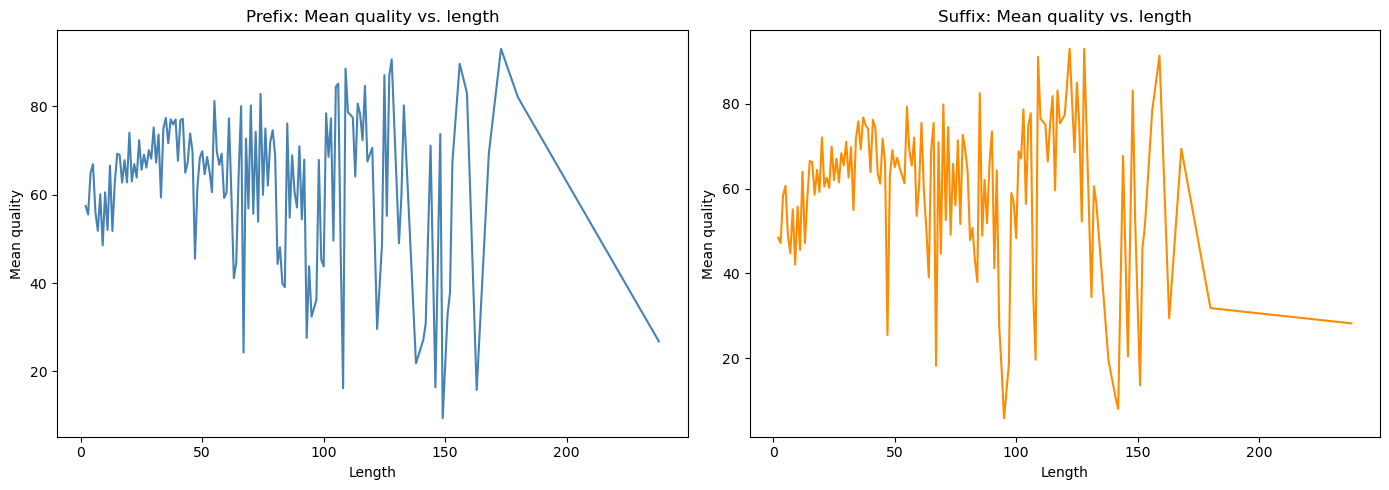

In [63]:
plot_mean_quality_vs_length(inserted_not_SNPs)

/tmp/12985220/ipykernel_468468/758779350.py:69: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/tmp/12985220/ipykernel_468468/758779350.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


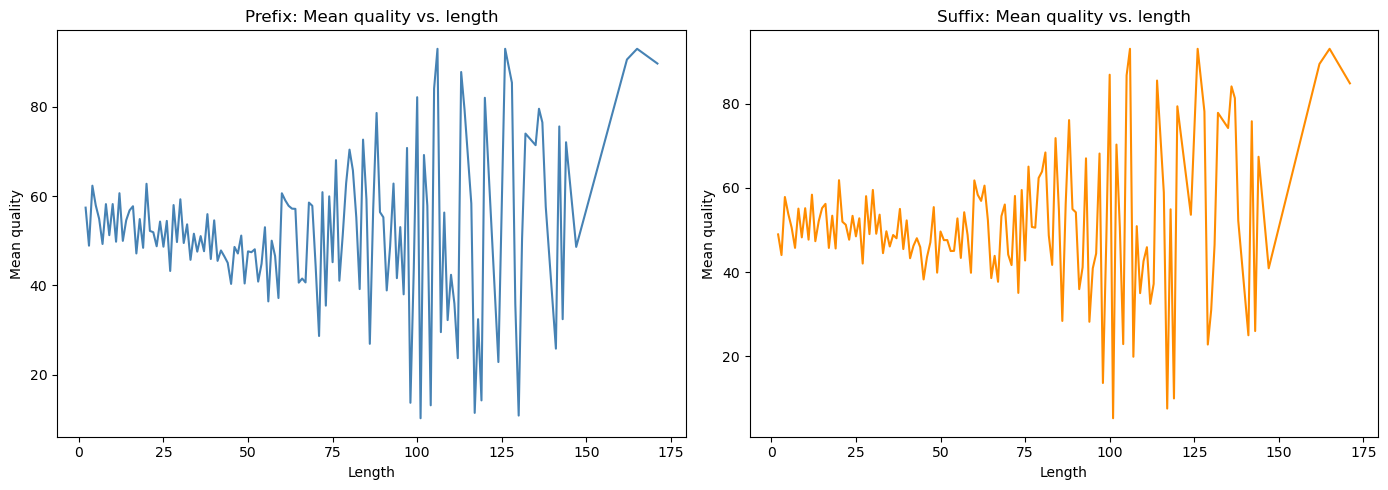

In [64]:
plot_mean_quality_vs_length(deleted_not_SNPs)

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_edge_quality_vs_length(
    df: pd.DataFrame,
    length_col: str = "length",
    prefix_col: str = "prefix_quality",
    suffix_col: str = "suffix_quality",
    figsize: tuple = (14, 5),
    palette: list = ["steelblue", "darkorange"],
    estimator: str = "mean",          # aggregation across identical lengths
    ci: int | None = None,           # confidence‑interval band; None → no band
) -> plt.Figure:
    """
    Plot the *last* quality value from the comma‑separated ``prefix_quality`` column
    and the *first* quality value from the comma‑separated ``suff_quality`` column
    as a function of ``length``.

    Parameters
    ----------
    df : pd.DataFrame
        Input table that must contain the three columns indicated by the arguments.
        The quality columns are strings of five comma‑separated numbers, e.g.
        ``"0.1,0.3,0.2,0.4,0.5"``.
    length_col, prefix_col, suffix_col : str, optional
        Column names in ``df``.
    figsize : tuple, optional
        Width and height of the returned figure.
    palette : list, optional
        Colours for the two plots (prefix‑last, suffix‑first).
    estimator : str, optional
        Aggregation used by ``sns.lineplot`` (``"mean"``, ``"median"``, …).
    ci : int or None, optional
        Size of the confidence interval band; ``None`` disables it.

    Returns
    -------
    plt.Figure
        The figure object containing the two sub‑plots.
    """

    # ----------------------------------------------------------------------
    #  Split the comma‑separated strings into five numeric columns each
    # ----------------------------------------------------------------------
    pref_parts = df[prefix_col].str.split(",", expand=True).astype(float)
    suff_parts = df[suffix_col].str.split(",", expand=True).astype(float)

    # ----------------------------------------------------------------------
    #  Extract the *edge* values we care about
    # ----------------------------------------------------------------------
    #   - last element of the prefix → column index 4 (0‑based)
    #   - first element of the suffix → column index 0
    pref_last = pref_parts.iloc[:, 4]          # 5th value
    suff_first = suff_parts.iloc[:, 0]         # 1st value

    # ----------------------------------------------------------------------
    #  Assemble tiny data frames for each series (length + value)
    # ----------------------------------------------------------------------
    pref_df = pd.DataFrame({
        length_col: df[length_col],
        "edge_quality": pref_last
    })
    suff_df = pd.DataFrame({
        length_col: df[length_col],
        "edge_quality": suff_first
    })

    # ----------------------------------------------------------------------
    #  Build two side‑by‑side axes
    # ----------------------------------------------------------------------
    fig, (ax_pref, ax_suff) = plt.subplots(1, 2, figsize=figsize)

    # Prefix – last position
    sns.lineplot(
        data=pref_df,
        x=length_col,
        y="edge_quality",
        markers=True,
        dashes=False,
        estimator=estimator,
        ci=ci,
        color=palette[0],
        ax=ax_pref,
    )
    ax_pref.set_title("Prefix: last quality value vs. length")
    ax_pref.set_xlabel("Length")
    ax_pref.set_ylabel("Quality (last)")

    # Suffix – first position
    sns.lineplot(
        data=suff_df,
        x=length_col,
        y="edge_quality",
        markers=True,
        dashes=False,
        estimator=estimator,
        ci=ci,
        color=palette[1],
        ax=ax_suff,
    )
    ax_suff.set_title("Suffix: first quality value vs. length")
    ax_suff.set_xlabel("Length")
    ax_suff.set_ylabel("Quality (first)")

    fig.tight_layout()

    # ----------------------------------------------------------------------
    #  Prevent double‑display in interactive notebooks
    # ----------------------------------------------------------------------
    plt.close(fig)          # stops the automatic Jupyter rendering
    return fig


/tmp/12985220/ipykernel_468468/203839673.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/tmp/12985220/ipykernel_468468/203839673.py:91: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


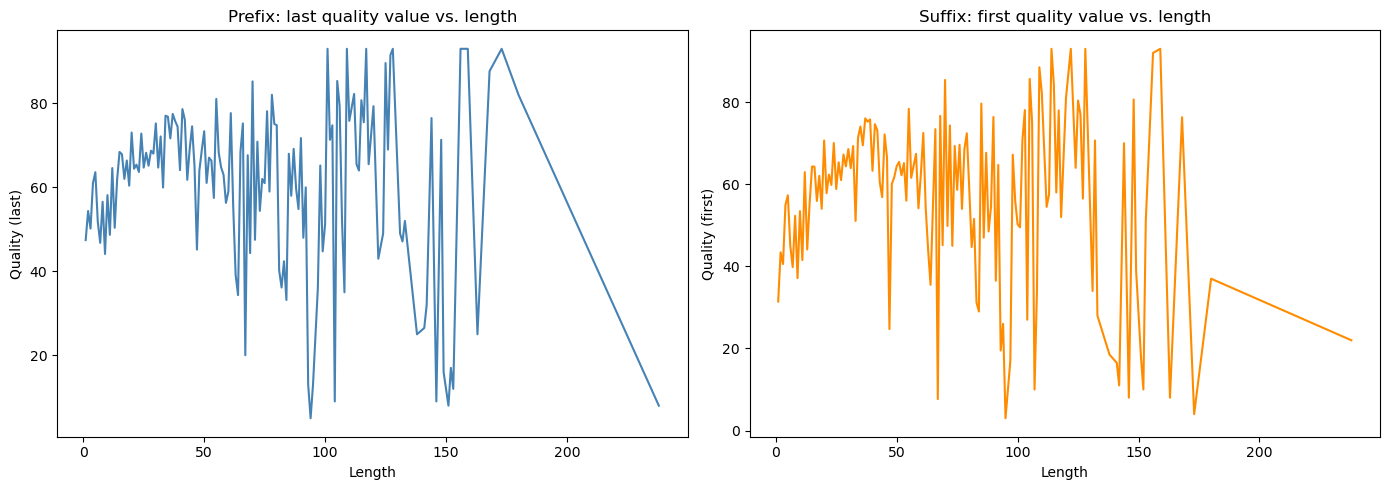

In [72]:
plot_edge_quality_vs_length(INSERTIONS)

/tmp/12985220/ipykernel_468468/203839673.py:75: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/tmp/12985220/ipykernel_468468/203839673.py:91: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


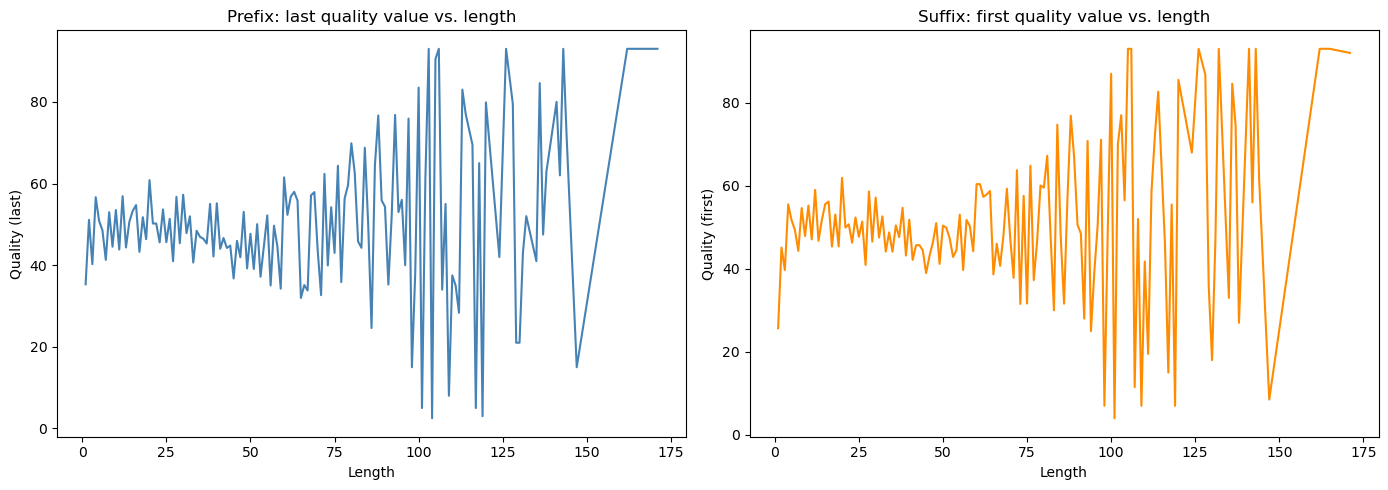

In [71]:
plot_edge_quality_vs_length(DELETIONS)

In [84]:
import pysam
def largest_contigs(fasta_path: Path, n: int = 10) -> None:
    """
    Print the `n` longest sequences (contigs) in *fasta_path*.

    Parameters
    ----------
    fasta_path : Path
        Path to the input FASTA (or FASTQ) file.
    n : int, optional
        How many top contigs to display (default = 10).
    """
   

    
    fasta = pysam.FastaFile(str(fasta_path))


    contig_lengths = []
    for name in fasta.references:
        length = fasta.get_reference_length(name)
        contig_lengths.append((length, name))


    top_n = sorted(contig_lengths, key=lambda x: x[0], reverse=True)[:n]

    
    for i, (length, name) in enumerate(top_n, start=1):

        print(f"{i:2d}. {name:<30} length = {length:,}")


    fasta.close()

In [85]:
largest_contigs(Path("/home/peterkad/pkadmaster/data/ph/ph_diploid.fa"), n=10)

KeyboardInterrupt: 